In [ ]:
#RANDOM FOREST PROJECT

In [2]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [3]:
df=pd.read_csv("/content/Invistico_Airline.csv")
df.head(4)

,Satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Online support
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,2
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,2
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3


In [4]:
df.shape

(129880, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 11 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   Satisfaction                       129880 non-null  object
 1   Gender                             129880 non-null  object
 2   Customer Type                      129880 non-null  object
 3   Age                                129880 non-null  int64 
 4   Type of Travel                     129880 non-null  object
 5   Class                              129880 non-null  object
 6   Flight Distance                    129880 non-null  int64 
 7   Seat comfort                       129880 non-null  int64 
 8   Departure/Arrival time convenient  129880 non-null  int64 
 9   Food and drink                     129880 non-null  int64 
 10  Online support                     129880 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 10.9+ MB


In [6]:
df.columns

Index(['Satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink',
       'Online support'],
      dtype='object')

In [7]:
## how to convert string to values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [8]:
df["Satisfaction"]=le.fit_transform(df["Satisfaction"])
df["Gender"]=le.fit_transform(df["Gender"])
df["Customer Type"]=le.fit_transform(df["Customer Type"])
df["Type of Travel"]=le.fit_transform(df["Type of Travel"])
df["Class"]=le.fit_transform(df["Class"])

In [9]:
df.describe()

,Satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Online support
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,0.547328,0.492616,0.183092,39.427957,0.309416,0.593864,1981.409055,2.838597,2.990645,2.851994,3.519703
std,0.497757,0.499947,0.386743,15.119360,0.462255,0.621378,1027.115606,1.392983,1.527224,1.443729,1.306511
min,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,27.000000,0.000000,0.000000,1359.000000,2.000000,2.000000,2.000000,3.000000
50%,1.000000,0.000000,0.000000,40.000000,0.000000,1.000000,1925.000000,3.000000,3.000000,3.000000,4.000000
75%,1.000000,1.000000,0.000000,51.000000,1.000000,1.000000,2544.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,1.000000,1.000000,85.000000,1.000000,2.000000,6951.000000,5.000000,5.000000,5.000000,5.000000


In [10]:
df.isna().sum()

,0
Satisfaction,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Seat comfort,0
Departure/Arrival time convenient,0
Food and drink,0


In [11]:
df.Gender.value_counts()

,count
Gender,
0,65899
1,63981


<Axes: xlabel='Gender', ylabel='count'>

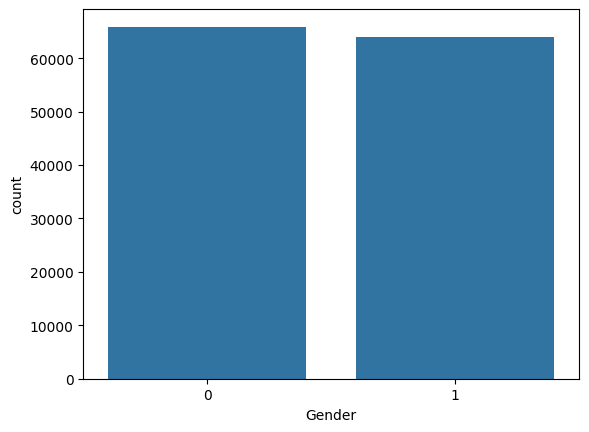

In [12]:
sn.countplot(x='Gender', data=df)

In [13]:
df.Age.value_counts()

,count
Age,
39,3692
25,3511
40,3209
44,3104
41,3089
...,...
74,61
76,60
79,52


<Axes: xlabel='Age', ylabel='count'>

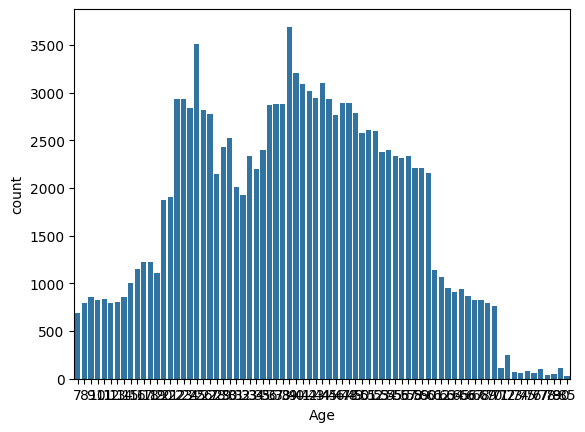

In [14]:
sn.countplot(x='Age',data=df)

<Axes: xlabel='Class'>

<Figure size 2000x1800 with 0 Axes>

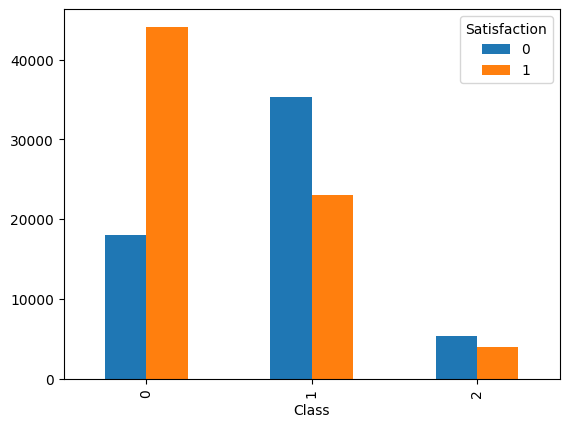

In [15]:
plt.figure(figsize=(20,18))
pd.crosstab(df.Class,df.Satisfaction).plot(kind="bar")

In [16]:
df.columns

Index(['Satisfaction', 'Gender', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink',
       'Online support'],
      dtype='object')

In [17]:
#removing the outlier
q1=df.quantile(0.0)   ## 25 %
q3=df.quantile(0.8)  ## 75 %
iqr=q3-q1

In [26]:
## to save in new dtaframe
df2=df[~((df<(q1-1.5*iqr))| (df>(q3+1.5*iqr)))]

In [27]:
df2.head(2)

,Satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Online support
0,1,0,0.0,65,1,1,265.0,0,0,0,2
1,1,1,0.0,47,1,0,2464.0,0,0,0,2


In [28]:
df3=df2.dropna()

In [29]:
df3.shape

(106085, 11)

In [30]:
x = df3[['Satisfaction', 'Customer Type', 'Age', 'Type of Travel',
       'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink',
       'Online support']]

In [31]:
y = df3['Gender']

In [32]:
x.shape,y.shape

((106085, 10), (106085,))

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [34]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()

In [35]:
model.fit(x_train,y_train)

RandomForestClassifier()

In [36]:
model.score(x_test,y_test)

0.6890700853089504

In [37]:
model.predict(x_test)

array([1, 1, 1, ..., 0, 0, 0])

In [38]:
y_predict=model.predict(x_test)

In [39]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.69      0.69      0.69     10604
           1       0.69      0.68      0.69     10613

    accuracy                           0.69     21217
   macro avg       0.69      0.69      0.69     21217
weighted avg       0.69      0.69      0.69     21217



In [40]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_predict)
cm

array([[7353, 3251],
       [3346, 7267]])

<Axes: >

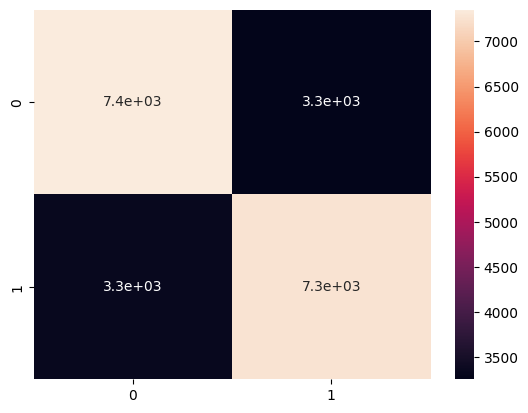

In [41]:
sn.heatmap(cm,annot=True)

Bagging (Bootstrapping)

In [42]:
from sklearn.ensemble import BaggingClassifier

In [43]:
model1=BaggingClassifier()

In [44]:
model1.fit(x_train,y_train)

BaggingClassifier()

In [45]:
model1.score(x_test,y_test)

0.6812933025404158

In [46]:
model1.predict(x_test)

array([1, 1, 1, ..., 0, 1, 0])

In [47]:
y_predict=model1.predict(x_test)

In [48]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.67      0.73      0.70     10604
           1       0.70      0.63      0.67     10613

    accuracy                           0.68     21217
   macro avg       0.68      0.68      0.68     21217
weighted avg       0.68      0.68      0.68     21217



Boosting (ADA Boosting, Gradient Boosting, XGB Boosting)

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

In [50]:
gb=GradientBoostingClassifier()

In [51]:
gb.fit(x_train,y_train)

GradientBoostingClassifier()

In [52]:
gb.score(x_test,y_test)

0.6825658669934487

In [53]:
gb.predict(x_test)

array([1, 0, 1, ..., 0, 1, 0])

In [54]:
y_predict = gb.predict(x_test)

In [55]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.70      0.64      0.67     10604
           1       0.67      0.72      0.70     10613

    accuracy                           0.68     21217
   macro avg       0.68      0.68      0.68     21217
weighted avg       0.68      0.68      0.68     21217



ADA BOOSTING

In [56]:
from sklearn.ensemble import AdaBoostClassifier

In [57]:
adab = AdaBoostClassifier()

In [58]:
adab.fit(x_train,y_train)

AdaBoostClassifier()

In [59]:
adab.score(x_test,y_test)

0.6526370363387849

In [60]:
adab.predict(x_test)

array([1, 1, 1, ..., 1, 1, 1])

In [61]:
y_predict = adab.predict(x_test)

In [62]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.66      0.63      0.64     10604
           1       0.65      0.68      0.66     10613

    accuracy                           0.65     21217
   macro avg       0.65      0.65      0.65     21217
weighted avg       0.65      0.65      0.65     21217



XG BOOSTING

In [63]:
from xgboost import XGBClassifier

In [64]:
xgb = XGBClassifier()

In [65]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [66]:
xgb.score(x_test,y_test)

0.6844511476646086

In [67]:
xgb.predict(x_test)

array([1, 1, 1, ..., 0, 1, 0])

In [68]:
y_predict = xgb.predict(x_test)

In [69]:
from sklearn.metrics import classification_report
clf=classification_report(y_test,y_predict)
print(clf)

              precision    recall  f1-score   support

           0       0.69      0.67      0.68     10604
           1       0.68      0.70      0.69     10613

    accuracy                           0.68     21217
   macro avg       0.68      0.68      0.68     21217
weighted avg       0.68      0.68      0.68     21217



In [70]:
xgb.feature_importances_

array([0.26493555, 0.        , 0.01235997, 0.550974  , 0.07265268,
       0.01640325, 0.04703421, 0.01062302, 0.01265526, 0.01236205],
      dtype=float32)

<Axes: >

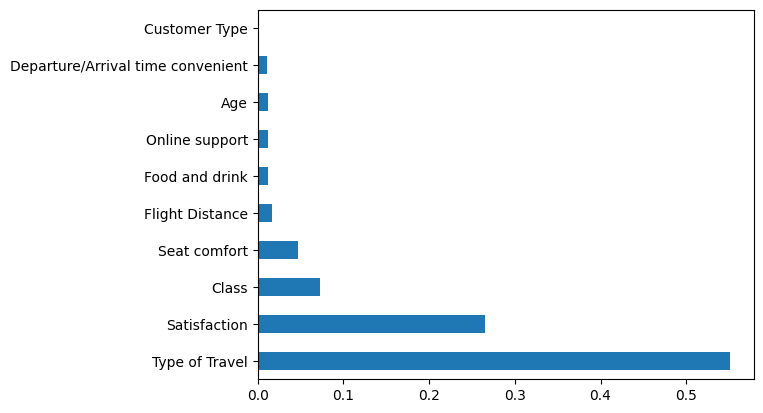

In [71]:
feature=pd.Series(xgb.feature_importances_,index=x.columns)
feature.nlargest(10).plot(kind='barh')